In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root='./data', 
    train=True,
    transform=transform, 
    download=True
)
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

100%|██████████| 9.91M/9.91M [00:19<00:00, 504kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 92.8kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 668kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.49MB/s]


In [3]:
len(train_dataset)

60000

In [4]:
train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=64,shuffle=True)

In [5]:
data_iter=iter(train_loader)
image,label=next(data_iter)

In [7]:
image[0].shape

torch.Size([1, 28, 28])

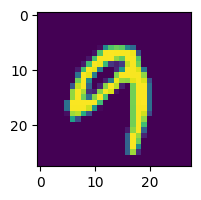

In [10]:
plt.figure(figsize=(2,2))
plt.imshow(image[0].squeeze())
plt.show()

In [13]:
label[0]

tensor(9)

In [23]:
class DigitsClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network=nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self,x):
        return self.network(x)

In [24]:
model=DigitsClassifier()
optimizer=optim.Adam(model.parameters(), lr=0.001)
criterion=nn.CrossEntropyLoss()

In [34]:
epochs=5
for epoch in range(epochs):
    running_loss=0.0
    for image, label in train_loader:
        output=model(image)
        loss=criterion(output,label)


        running_loss +=loss.item()
        
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss / len(train_loader):.4f}")

Epoch [1/5], Loss: 0.0555
Epoch [2/5], Loss: 0.0505
Epoch [3/5], Loss: 0.0482
Epoch [4/5], Loss: 0.0429
Epoch [5/5], Loss: 0.0423


In [64]:
model.eval()

total=0
correct=0

with torch.no_grad():
    for image, label in test_loader:
        output=model(image)
        _,predicted=torch.max(output.data,1)
        correct +=(predicted == label).sum().item()
        total +=label.size(0)
print(f'Accuracy on the test set: {100 * correct / total:.2f}%')

Accuracy on the test set: 96.82%


In [65]:
# Testing the model
model.eval()  # Switch to evaluation mode

all_predicted = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        # Append labels and predictions to lists
        all_labels.extend(labels.numpy())    
        all_predicted.extend(predicted.numpy()) 

In [66]:
from sklearn.metrics import classification_report

report = classification_report(all_labels, all_predicted)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.98      1.00      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.93      0.99      0.96      1010
           4       0.96      0.99      0.97       982
           5       0.97      0.95      0.96       892
           6       0.94      0.99      0.97       958
           7       0.98      0.97      0.97      1028
           8       0.99      0.93      0.96       974
           9       0.99      0.92      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_predicted)
cm

array([[ 965,    1,    1,    1,    0,    3,    8,    1,    0,    0],
       [   0, 1131,    1,    1,    1,    0,    1,    0,    0,    0],
       [   6,    3, 1000,    4,    2,    0,    9,    5,    3,    0],
       [   0,    0,    6,  999,    0,    3,    0,    2,    0,    0],
       [   0,    0,    0,    0,  969,    2,    7,    1,    0,    3],
       [   3,    1,    0,   25,    0,  846,   15,    1,    1,    0],
       [   1,    2,    0,    1,    2,    2,  948,    0,    2,    0],
       [   1,   13,    9,    3,    1,    1,    0,  995,    0,    5],
       [   6,    0,    8,   22,    5,    8,   16,    5,  901,    3],
       [   4,    7,    2,   15,   33,   10,    1,    6,    3,  928]])

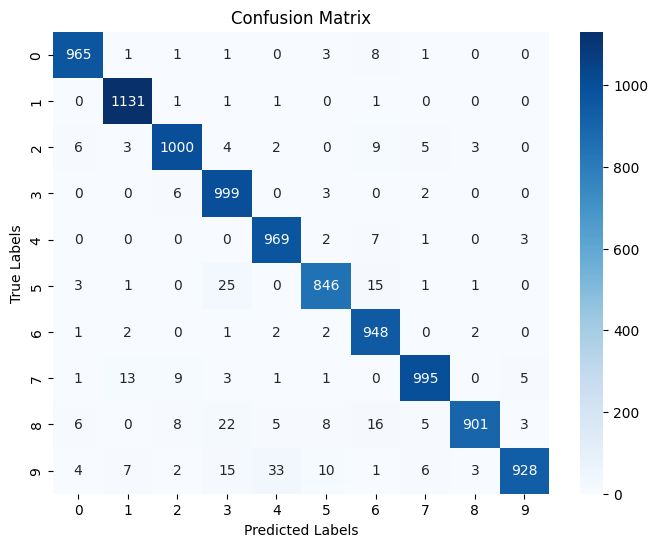

In [68]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(len(cm)), yticklabels=range(len(cm)))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()